In [1]:
import pandas as pd
df=pd.read_csv('ab_test_data.csv')
df.head()


,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 4:40:56,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 0:26:45,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:34,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 7:04:50,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50,b,0


In [2]:
df['timestamp']=pd.to_datetime(df['timestamp'])

In [3]:
ozet=df.groupby('test_group')['conversion'].agg(['count','sum']).reset_index()
ozet.columns=['grup','kullanıcı sayısı','dönüşüm sayısı']
ozet['dönüşüm oranı']=ozet['dönüşüm sayısı']/ozet['kullanıcı sayısı']
print (ozet)

  grup  kullanıcı sayısı  dönüşüm sayısı  dönüşüm oranı
0    a             10013             611       0.061021
1    b              9985             889       0.089034


In [4]:
#Test Süresini Hesaplama
baslangic=df['timestamp'].min()
bitis=df['timestamp'].max()
sure=(bitis-baslangic).days

print(f"Test Başlangıcı:{baslangic}")
print(f"Test Bitişi:{bitis}")
print(f"Test Süresi: {sure} gün")

Test Başlangıcı:2023-07-03 01:42:34
Test Bitişi:2023-07-25 01:41:19
Test Süresi: 21 gün


In [11]:
#hipotezler
#H0: pA = pB (dönüşüm oranları eşit)
#H1: pA ≠ pB (veya tek yönlü: pB > pA)

##hipotez testi
from statsmodels.stats.proportion import proportions_ztest
basarilar = [889, 611]    # Grup B ve Grup A'nın dönüşüm sayıları
toplamlar = [9985, 10013] # Grup B ve Grup A'nın toplam kullanıcı sayıları
z_istatistik,p_degeri=proportions_ztest(count=basarilar,nobs=toplamlar)
print(f"Z-İstatistiği: {z_istatistik:.4f}")
print(f"p-değeri: {p_degeri:.14f}")

Z-İstatistiği: 7.5197
p-değeri: 0.00000000000005


In [12]:
###Etki Büyüklüğü (Lift) Hesaplama
p_a=611/10013
p_b=889/9985

absolute_lift = p_b - p_a
relative_lift = (p_b - p_a) / p_a
print(f"Absolute Lift: {absolute_lift:.4f}")
print(f"Relative Lift (Artış Oranı): %{relative_lift*100:.2f}")

Absolute Lift: 0.0280
Relative Lift (Artış Oranı): %45.91


In [ ]:
###Karar: p < 0.05 olduğu için H0 reddedilir. Yani indirimli teklif (Grup B) istatistiksel olarak anlamlı bir şekilde daha başarılıdır.

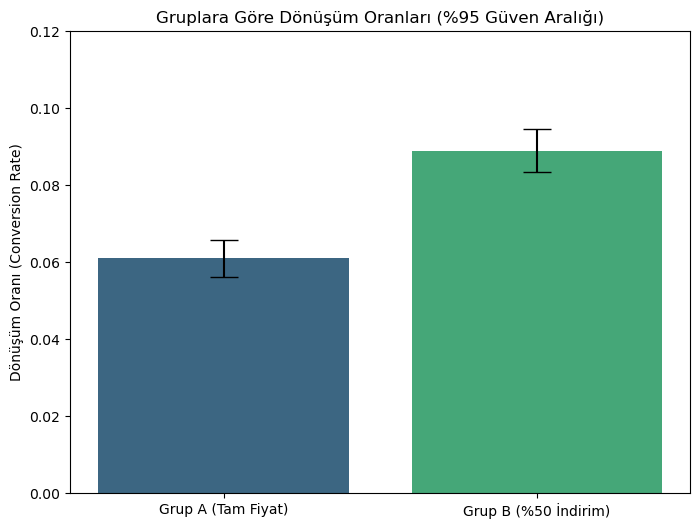

In [9]:
#95% Güven Aralığı ile Karşılaştırma Görselleştirmesi

##guven aralıgı olusturma
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def guven_araligi_hesapla(p, n):
    hata_payi = 1.96 * np.sqrt((p * (1 - p)) / n)
    return hata_payi
    
p_a, n_a = 0.0610, 10013
p_b, n_b = 0.0890, 9985

hata_a = guven_araligi_hesapla(p_a, n_a)
hata_b = guven_araligi_hesapla(p_b, n_b)

#gorsellestırme

plt.figure(figsize=(8, 6))
gruplar = ['Grup A (Tam Fiyat)', 'Grup B (%50 İndirim)']
oranlar = [p_a, p_b]
hatalar = [hata_a, hata_b]

sns.barplot(x=gruplar, y=oranlar, hue=gruplar, palette='viridis', legend=False)
plt.errorbar(x=[0, 1], y=oranlar, yerr=hatalar, fmt='none', c='black', capsize=10)

plt.title('Gruplara Göre Dönüşüm Oranları (%95 Güven Aralığı)')
plt.ylabel('Dönüşüm Oranı (Conversion Rate)')
plt.ylim(0, 0.12) # Grafiğin üstten biraz boşluğu olsun
plt.show()

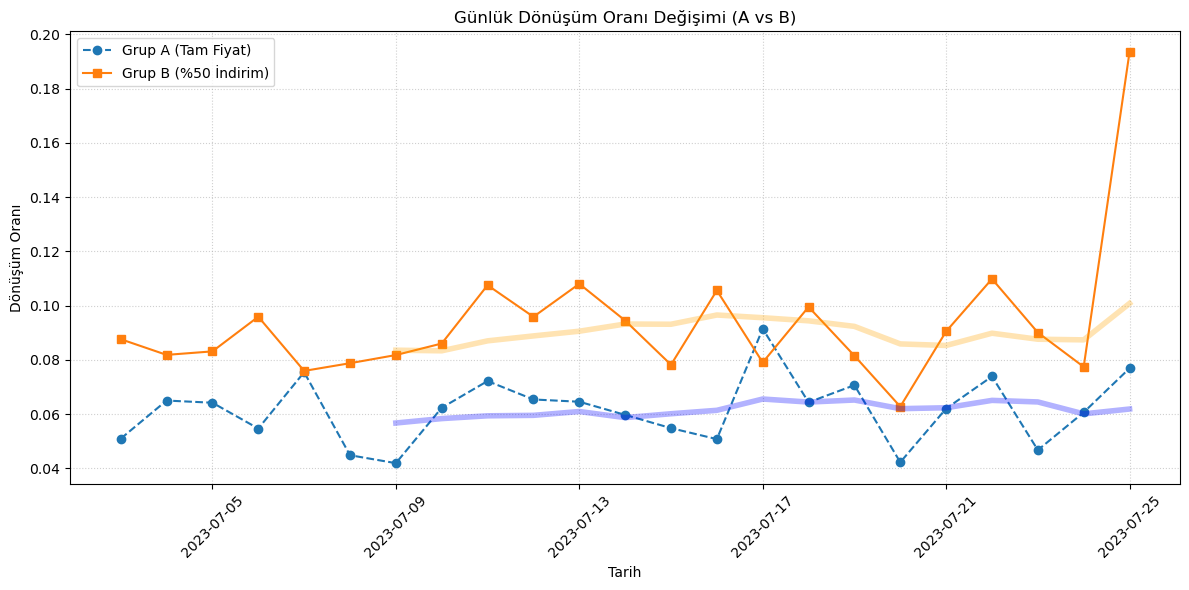

In [10]:
# #bonus odev
df['date'] = df['timestamp'].dt.date
zaman_serisi = df.groupby(['date', 'test_group'])['conversion'].mean().unstack()

# Grafik Çizimi
plt.figure(figsize=(12, 6))
plt.plot(zaman_serisi.index, zaman_serisi['a'], label='Grup A (Tam Fiyat)', marker='o', linestyle='--')
plt.plot(zaman_serisi.index, zaman_serisi['b'], label='Grup B (%50 İndirim)', marker='s', linestyle='-')

plt.plot(zaman_serisi['a'].rolling(window=7).mean(), color='blue', alpha=0.3, linewidth=4)
plt.plot(zaman_serisi['b'].rolling(window=7).mean(), color='orange', alpha=0.3, linewidth=4)

plt.title('Günlük Dönüşüm Oranı Değişimi (A vs B)')
plt.xlabel('Tarih')
plt.ylabel('Dönüşüm Oranı')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()